In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
import skimage
import scipy

In [2]:
pheno_triax = np.load('./data/pheno_triax.npy')
dislo_triax = np.load('./data/dislo_triax.npy')

In [3]:
material_IDs = np.load('./polycrystal_128_VE_material_IDs.npy')

Extract grain boundaries

In [4]:
grain_boundaries = skimage.segmentation.find_boundaries(label_img=material_IDs, connectivity = 3, mode = 'subpixel')

In [5]:
# Convert array to float (True -> 1.0 and False -> 0)
grain_boundaries_float = grain_boundaries.astype(float)

# Replace all false values with NaNs
grain_boundaries_float[grain_boundaries_float == 0.0] = np.nan

print(grain_boundaries_float)

[[[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan  1.  1. ... nan nan nan]
  [nan  1.  1. ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan  1.  1. ... nan nan nan]
  [nan  1. nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 ...

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]]

 [[nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  ...
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan nan]
  [nan nan nan ... nan nan n

In [102]:
np.save('polycrystal_128_cubed_1000_grains_boundaries.npy', grain_boundaries_float)

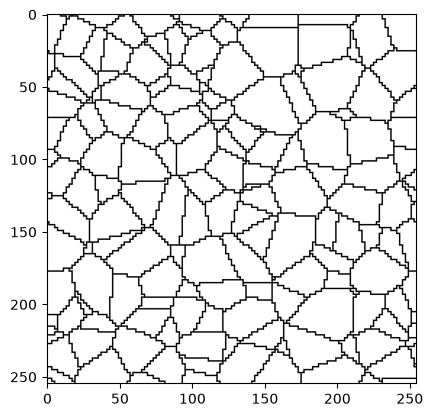

In [6]:
%matplotlib inline
plt.imshow(np.flip(grain_boundaries_float[:,:,0].transpose(), axis=0), cmap='grey')
plt.show()

In [7]:
grain_boundaries_float.shape

(255, 255, 255)

Locating distance from GB

In [8]:
grid = pv.read("polycrystal_128_geom.vti")

grid.spacing, grid.origin, grid.dimensions

((7.8125e-06, 7.8125e-06, 7.8125e-06), (0.0, 0.0, 0.0), (129, 129, 129))

In [9]:
size = [1.0e-3, 1.0e-3, 1.0e-3]
voxels = [128,128,128]
voxels_255 = [255,255,255]

In [10]:
# Creating voxel coordinates for 128^3 VE
start = np.array(grid.origin)         + (np.array(size)/np.array(voxels))*0.5 # Add voxel centre offset
end = np.array(grid.origin) + np.array(size)   - (np.array(size)/np.array(voxels))*0.5 # Add voxel offset
    
voxel_coords = np.stack(np.meshgrid(np.linspace(start[0],end[0],voxels[0]),
                                           np.linspace(start[1],end[1],voxels[1]),
                                           np.linspace(start[2],end[2],voxels[2]),
                                           indexing='ij'),
                                           axis=-1)
voxel_coords.shape                         

(128, 128, 128, 3)

In [11]:
# Creating voxel coordinates for 255^3 VE (where grain boundaries are located)
start_255 = np.array(grid.origin)         + (np.array(size)/np.array(voxels_255))*0.5 # Add voxel centre offset
end_255 = np.array(grid.origin) + np.array(size)   - (np.array(size)/np.array(voxels_255))*0.5 # Add voxel offset

voxel_coords_255 = np.stack(np.meshgrid(np.linspace(start_255[0],end_255[0],voxels_255[0]),
                                           np.linspace(start_255[1],end_255[1],voxels_255[1]),
                                           np.linspace(start_255[2],end_255[2],voxels_255[2]),
                                           indexing='ij'),
                                           axis=-1)

voxel_coords_255.shape                                        

(255, 255, 255, 3)

In [12]:
grain_boundaries_flat = grain_boundaries_float.flatten(order = 'F')
voxel_coords_255_flat = voxel_coords_255.reshape((255**3, 3), order = 'F')

In [13]:
grain_boundaries_flat.shape, voxel_coords_255_flat.shape

((16581375,), (16581375, 3))

In [14]:
len(np.where(grain_boundaries_flat == 1)[0])/255**3

0.15878068013056817

In [15]:
grain_boundary_coords = np.empty(voxel_coords_255_flat.shape)
grain_boundary_coords[:] = np.nan
print(grain_boundary_coords)

[[nan nan nan]
 [nan nan nan]
 [nan nan nan]
 ...
 [nan nan nan]
 [nan nan nan]
 [nan nan nan]]


In [16]:
# Extracting coordinates for location of grain boundaries
for i in range(len(grain_boundaries_flat)):
    if grain_boundaries_flat[i] == 1:
        grain_boundary_coords[i] = voxel_coords_255_flat[i]

In [17]:
(len(np.where(grain_boundary_coords == voxel_coords_255_flat)[0])/3)/255**3

0.15878068013056817

In [18]:
grain_boundary_coords_no_nan = grain_boundary_coords[~np.isnan(grain_boundary_coords).any(axis=1)]

In [19]:
grain_boundary_coords_no_nan.shape

(2632802, 3)

In [20]:
tree = scipy.spatial.KDTree(grain_boundary_coords_no_nan, boxsize=[1.0e-3, 1.0e-3, 1.0e-3])

In [64]:
gb_distance = tree.query(voxel_coords.reshape(-1,voxel_coords.shape[-1]), workers=8,p=2)[0] # Index 0 gives distance from GB, index 1 gives index of nearest GB

In [65]:
gb_distance

array([3.42271070e-06, 3.38770329e-06, 3.35261032e-06, ...,
       1.02153425e-05, 1.39878698e-05, 1.69543576e-05], shape=(2097152,))

# Plots against triaxiality value

In [23]:
pheno_triax_flat = pheno_triax.flatten(order = 'F')
dislo_triax_flat = dislo_triax.flatten(order = 'F')

(array([5.70770e+04, 1.73764e+05, 1.72688e+05, 1.45099e+05, 1.34255e+05,
        1.19164e+05, 1.10126e+05, 8.32460e+04, 5.84430e+04, 4.17190e+04,
        2.53710e+04, 1.25100e+04, 4.74700e+03, 2.20200e+03, 2.74100e+04,
        5.10180e+04, 6.98890e+04, 7.07940e+04, 6.04800e+04, 5.13130e+04,
        3.83350e+04, 2.32060e+04, 1.90800e+04, 1.96410e+04, 2.56660e+04,
        2.90890e+04, 2.97000e+04, 2.63780e+04, 2.59500e+04, 2.43610e+04,
        2.23490e+04, 2.04930e+04, 1.91100e+04, 2.34020e+04, 2.19520e+04,
        2.01300e+04, 1.56140e+04, 1.38890e+04, 1.45520e+04, 1.19330e+04,
        1.02060e+04, 9.71200e+03, 1.21120e+04, 1.29700e+04, 1.14110e+04,
        1.12770e+04, 1.13030e+04, 1.09640e+04, 9.34500e+03, 6.47600e+03,
        5.87100e+03, 5.44500e+03, 4.94400e+03, 4.41800e+03, 4.92100e+03,
        5.42200e+03, 4.96600e+03, 4.84100e+03, 4.01200e+03, 3.32700e+03,
        2.99800e+03, 2.60500e+03, 2.22000e+03, 2.38000e+03, 2.34900e+03,
        1.90700e+03, 1.69800e+03, 1.33200e+03, 1.09

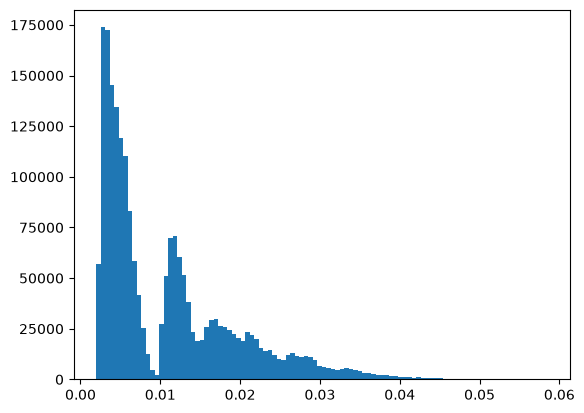

In [24]:
plt.hist(gb_distance/1.0e-3, bins = 100)

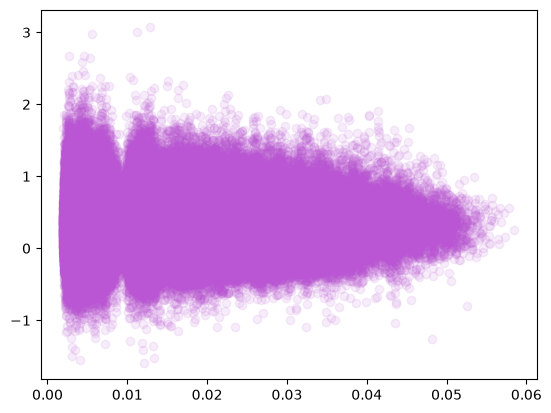

In [25]:
plt.scatter(gb_distance/1.0e-3, pheno_triax_flat, color = 'mediumorchid', alpha = 0.1)

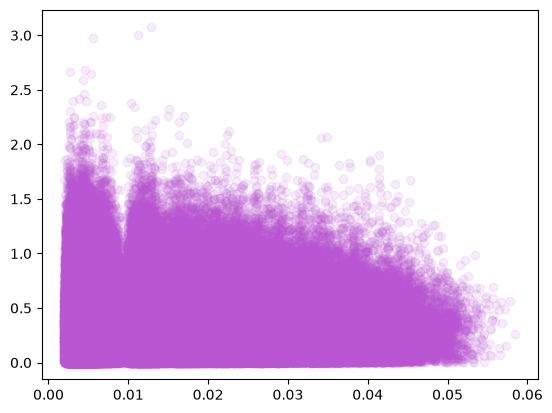

In [26]:
plt.scatter(gb_distance/1.0e-3, np.abs(pheno_triax_flat), color = 'mediumorchid', alpha = 0.1)

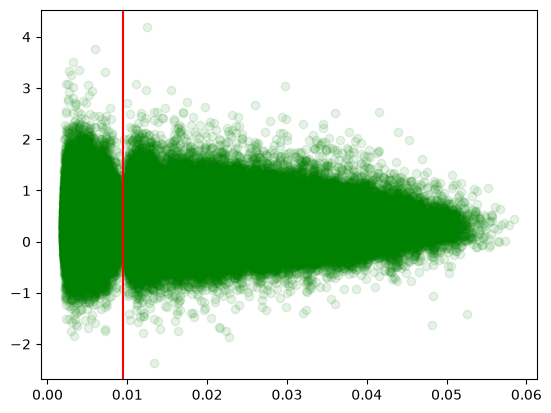

In [27]:
plt.scatter(gb_distance/1.0e-3, dislo_triax_flat, color = 'green', alpha = 0.1)
plt.axvline(0.0094, color = 'r')

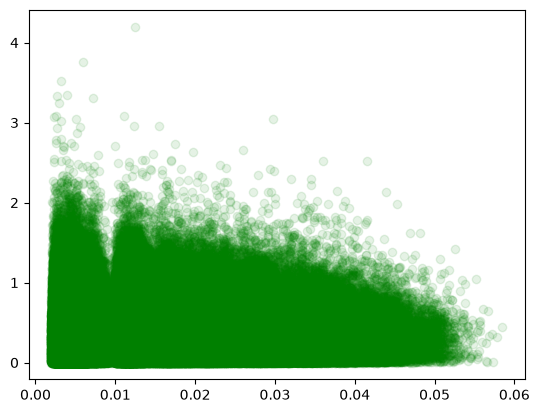

In [28]:
plt.scatter(gb_distance/1.0e-3, np.abs(dislo_triax_flat), color = 'green', alpha = 0.1)

Significant decrease in triaxiality for both models when distance from GB is 1% the VE size

# Plotting against mean equivalent grain diameter

In [29]:
grid.spacing[0]

7.8125e-06

In [30]:
voxel_volume = grid.spacing[0]**3
grain_diameters = []
for i in range(0, 1000):
    counts = len(np.where(material_IDs == i)[0])
    grain_volume = counts*voxel_volume
    grain_diameter = np.cbrt((6*grain_volume)/np.pi)
    grain_diameters.append(grain_diameter)

In [31]:
np.mean(grain_diameters)/1.0e-3

np.float64(0.12151104612777133)

In [32]:
max(grain_diameters)/min(grain_diameters)

np.float64(2.436670147906668)

In [33]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'

Text(0, 0.5, 'Stress triaxiality, $T_\\sigma$')

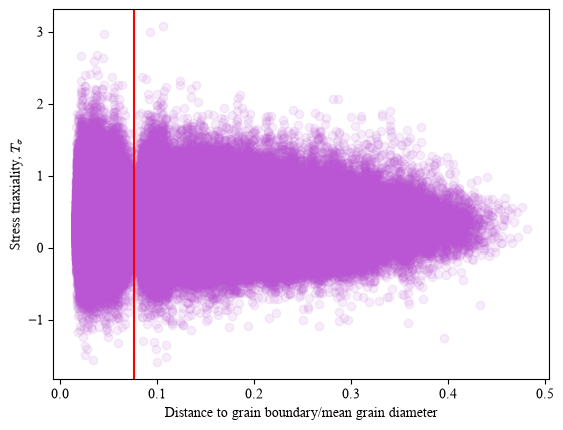

In [34]:
plt.scatter(gb_distance/np.mean(grain_diameters), pheno_triax_flat, color = 'mediumorchid', alpha = 0.1)
plt.axvline(0.076, color = 'r')
plt.xlabel('Distance to grain boundary/mean grain diameter')
plt.ylabel(r'Stress triaxiality, $T_\sigma$', math_fontfamily = 'cm')

Text(0, 0.5, 'Stress triaxiality, $T_\\sigma$')

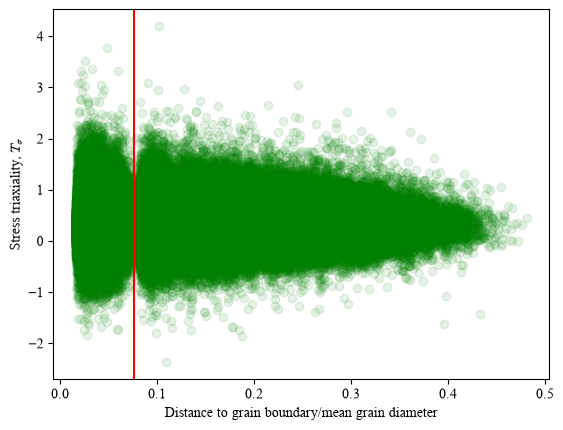

In [35]:
plt.scatter(gb_distance/np.mean(grain_diameters), dislo_triax_flat, color = 'green', alpha = 0.1)
plt.axvline(0.076, color = 'r')
plt.xlabel('Distance to grain boundary/mean grain diameter')
plt.ylabel(r'Stress triaxiality, $T_\sigma$', math_fontfamily = 'cm')

In [36]:
gb_distance_norm_grain_diameter = gb_distance/np.mean(grain_diameters)

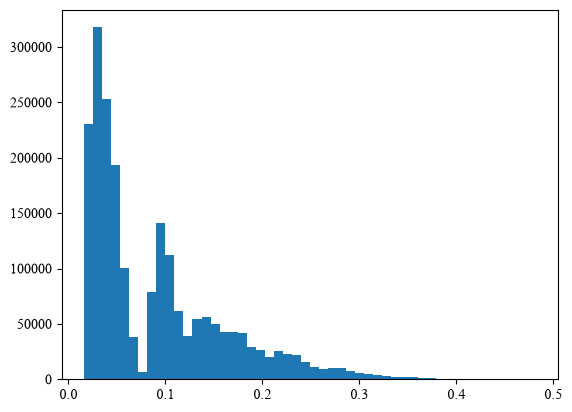

In [183]:
gb_distance_mean_diameter_norm_counts, gb_distance_mean_diameter_norm_bins, _ = plt.hist(gb_distance_norm_grain_diameter, bins = 50) 

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100)),
 array([0.01626372, 0.02091307, 0.02556242, 0.03021176, 0.03486111,
        0.03951046, 0.04415981, 0.04880915, 0.0534585 , 0.05810785,
        0.0627572 , 0.06740655, 0.07205589, 0.07670524, 0.08135459,
        0.08600394, 0.09065328, 0.09530263, 0.09995198, 0.10460133,
        0.10925067, 0.11390002, 0.11854937, 0.12319872, 0.12784807,
        0.13249741, 0.13714676, 0.14179611, 0.14644546, 0.1510948 ,
        0.15574415, 0.1603935 , 0.16504285, 0.16969219, 0.17434154,
        0.17899089, 0.18364024, 0.18828959, 0.19293893, 0.19758828,
        0.20223763, 0.20688698, 0.21153632, 0.21618567, 0.22083502,
        0.22548437, 0.23013372, 0.23478306, 0.23943241, 0.24408176,
        0.24873111, 0.25338045, 0.2580298 , 0.2626791

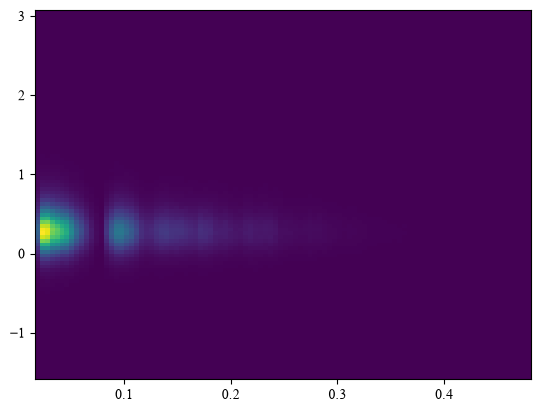

In [37]:
plt.hist2d(gb_distance/np.mean(grain_diameters), pheno_triax_flat, bins = 100)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100)),
 array([0.01626372, 0.02091307, 0.02556242, 0.03021176, 0.03486111,
        0.03951046, 0.04415981, 0.04880915, 0.0534585 , 0.05810785,
        0.0627572 , 0.06740655, 0.07205589, 0.07670524, 0.08135459,
        0.08600394, 0.09065328, 0.09530263, 0.09995198, 0.10460133,
        0.10925067, 0.11390002, 0.11854937, 0.12319872, 0.12784807,
        0.13249741, 0.13714676, 0.14179611, 0.14644546, 0.1510948 ,
        0.15574415, 0.1603935 , 0.16504285, 0.16969219, 0.17434154,
        0.17899089, 0.18364024, 0.18828959, 0.19293893, 0.19758828,
        0.20223763, 0.20688698, 0.21153632, 0.21618567, 0.22083502,
        0.22548437, 0.23013372, 0.23478306, 0.23943241, 0.24408176,
        0.24873111, 0.25338045, 0.2580298 , 0.2626791

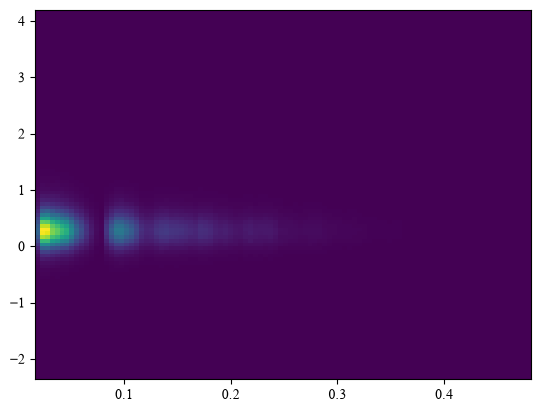

In [38]:
plt.hist2d(gb_distance/np.mean(grain_diameters), dislo_triax_flat, bins = 100)

# Plotting median triaxiality against distance from grain boundary

In [39]:
gb_distance_bins = np.linspace(min(gb_distance_norm_grain_diameter), max(gb_distance_norm_grain_diameter), 50)
gb_distance_bin_indices = np.digitize(gb_distance_norm_grain_diameter, bins = gb_distance_bins)

In [40]:
gb_distance_bins

array([0.01626372, 0.02575219, 0.03524065, 0.04472911, 0.05421758,
       0.06370604, 0.07319451, 0.08268297, 0.09217144, 0.1016599 ,
       0.11114837, 0.12063683, 0.1301253 , 0.13961376, 0.14910223,
       0.15859069, 0.16807916, 0.17756762, 0.18705609, 0.19654455,
       0.20603301, 0.21552148, 0.22500994, 0.23449841, 0.24398687,
       0.25347534, 0.2629638 , 0.27245227, 0.28194073, 0.2914292 ,
       0.30091766, 0.31040613, 0.31989459, 0.32938306, 0.33887152,
       0.34835999, 0.35784845, 0.36733691, 0.37682538, 0.38631384,
       0.39580231, 0.40529077, 0.41477924, 0.4242677 , 0.43375617,
       0.44324463, 0.4527331 , 0.46222156, 0.47171003, 0.48119849])

In [41]:
median_pheno_triax = []
median_dislo_triax = []
mean_pheno_triax = []
mean_dislo_triax = []
pheno_q5 = []
dislo_q5 = []
pheno_q95 = []
dislo_q95 = []
bin_centres = []

for i in range(1, len(gb_distance_bins)):
    mask = gb_distance_bin_indices == i

    if np.any(mask) and (np.sum(gb_distance_bin_indices == i) > 50):
        pheno_vals = pheno_triax_flat[mask]
        dislo_vals = dislo_triax_flat[mask]
        median_pheno_triax.append(np.median(pheno_vals))
        mean_pheno_triax.append(np.mean(pheno_vals))
        median_dislo_triax.append(np.median(dislo_vals))
        mean_dislo_triax.append(np.mean(dislo_vals))

        pheno_q5.append(np.percentile(pheno_vals, 5))
        dislo_q5.append(np.percentile(dislo_vals, 5))
        pheno_q95.append(np.percentile(pheno_vals, 95))
        dislo_q95.append(np.percentile(dislo_vals, 95))

        bin_centres.append(0.5 * (gb_distance_bins[i-1] + gb_distance_bins[i]))

In [42]:
counts_per_bin = [np.sum(gb_distance_bin_indices == i) for i in range(len(gb_distance_bins))]

In [43]:
np.array(counts_per_bin), gb_distance_bins

(array([     0, 238603, 322150, 254449, 191571,  95474,  32948,   9228,
         95548, 143300, 105283,  52783,  42168,  58854,  55168,  49416,
         40727,  45535,  38455,  29311,  23661,  21724,  25000,  23104,
         20786,  12687,  10515,   9646,  10489,   8845,   6284,   4972,
          4558,   3497,   2382,   1902,   1861,   1370,    989,    619,
           388,    298,    266,    166,     87,     40,     23,     13,
             6,      2]),
 array([0.01626372, 0.02575219, 0.03524065, 0.04472911, 0.05421758,
        0.06370604, 0.07319451, 0.08268297, 0.09217144, 0.1016599 ,
        0.11114837, 0.12063683, 0.1301253 , 0.13961376, 0.14910223,
        0.15859069, 0.16807916, 0.17756762, 0.18705609, 0.19654455,
        0.20603301, 0.21552148, 0.22500994, 0.23449841, 0.24398687,
        0.25347534, 0.2629638 , 0.27245227, 0.28194073, 0.2914292 ,
        0.30091766, 0.31040613, 0.31989459, 0.32938306, 0.33887152,
        0.34835999, 0.35784845, 0.36733691, 0.37682538, 0.38631384

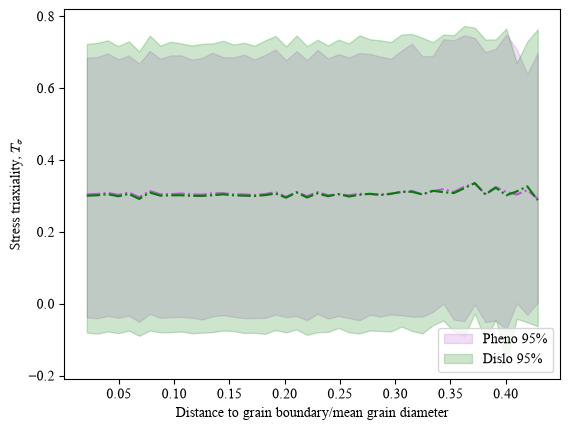

In [44]:
#plt.plot(bin_centres, median_pheno_triax, color = 'mediumorchid')
plt.plot(bin_centres, mean_pheno_triax, color = 'mediumorchid', ls = '-.')
plt.fill_between(bin_centres, pheno_q5, pheno_q95, color = 'mediumorchid', alpha=0.2, label='Pheno 95%')
#plt.plot(bin_centres, median_dislo_triax, color = 'green')
plt.plot(bin_centres, mean_dislo_triax, color = 'green', ls = '-.')
plt.fill_between(bin_centres, dislo_q5, dislo_q95, color = 'green', alpha=0.2, label='Dislo 95%')
plt.xlabel('Distance to grain boundary/mean grain diameter')
plt.ylabel(r'Stress triaxiality, $T_\sigma$', math_fontfamily = 'cm')
plt.legend()

# In terms of number of voxels from GBs

Text(0, 0.5, 'Stress triaxiality, $T_\\sigma$')

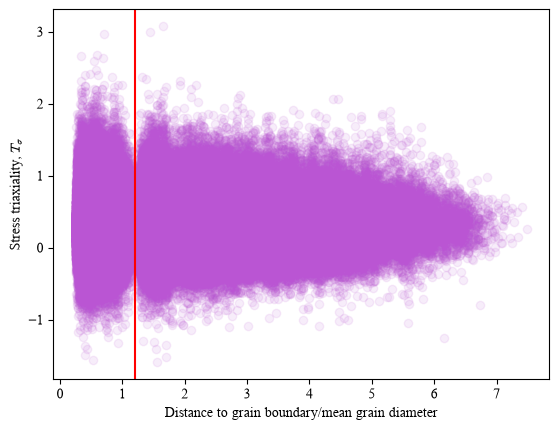

In [45]:
plt.scatter(gb_distance/grid.spacing[0], pheno_triax_flat, color = 'mediumorchid', alpha = 0.1)
plt.axvline(1.2, color = 'r')
plt.xlabel('Distance to grain boundary/mean grain diameter')
plt.ylabel(r'Stress triaxiality, $T_\sigma$', math_fontfamily = 'cm')

Text(0, 0.5, 'Stress triaxiality, $T_\\sigma$')

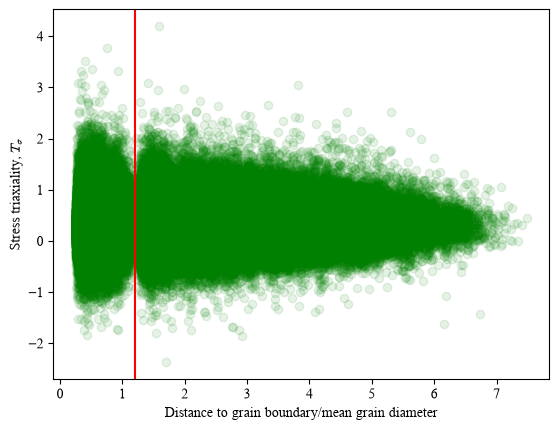

In [46]:
plt.scatter(gb_distance/grid.spacing[0], dislo_triax_flat, color = 'green', alpha = 0.1)
plt.axvline(1.2, color = 'r')
plt.xlabel('Distance to grain boundary/mean grain diameter')
plt.ylabel(r'Stress triaxiality, $T_\sigma$', math_fontfamily = 'cm')

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100)),
 array([0.25295638, 0.32526961, 0.39758283, 0.46989606, 0.54220929,
        0.61452252, 0.68683575, 0.75914898, 0.83146221, 0.90377544,
        0.97608867, 1.0484019 , 1.12071513, 1.19302836, 1.26534159,
        1.33765482, 1.40996804, 1.48228127, 1.5545945 , 1.62690773,
        1.69922096, 1.77153419, 1.84384742, 1.91616065, 1.98847388,
        2.06078711, 2.13310034, 2.20541357, 2.2777268 , 2.35004003,
        2.42235326, 2.49466648, 2.56697971, 2.63929294, 2.71160617,
        2.7839194 , 2.85623263, 2.92854586, 3.00085909, 3.07317232,
        3.14548555, 3.21779878, 3.29011201, 3.36242524, 3.43473847,
        3.5070517 , 3.57936492, 3.65167815, 3.72399138, 3.79630461,
        3.86861784, 3.94093107, 4.0132443 , 4.0855575

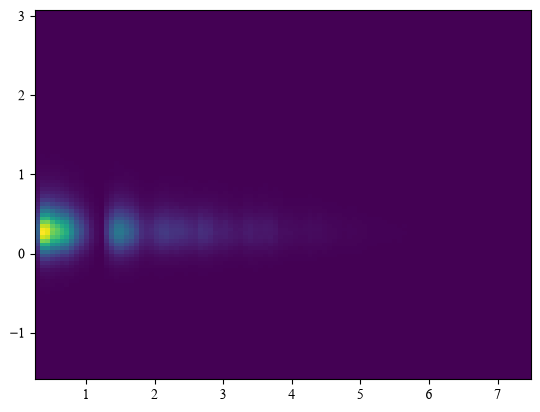

In [47]:
plt.hist2d(gb_distance/grid.spacing[0], pheno_triax_flat, bins = 100)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100)),
 array([0.25295638, 0.32526961, 0.39758283, 0.46989606, 0.54220929,
        0.61452252, 0.68683575, 0.75914898, 0.83146221, 0.90377544,
        0.97608867, 1.0484019 , 1.12071513, 1.19302836, 1.26534159,
        1.33765482, 1.40996804, 1.48228127, 1.5545945 , 1.62690773,
        1.69922096, 1.77153419, 1.84384742, 1.91616065, 1.98847388,
        2.06078711, 2.13310034, 2.20541357, 2.2777268 , 2.35004003,
        2.42235326, 2.49466648, 2.56697971, 2.63929294, 2.71160617,
        2.7839194 , 2.85623263, 2.92854586, 3.00085909, 3.07317232,
        3.14548555, 3.21779878, 3.29011201, 3.36242524, 3.43473847,
        3.5070517 , 3.57936492, 3.65167815, 3.72399138, 3.79630461,
        3.86861784, 3.94093107, 4.0132443 , 4.0855575

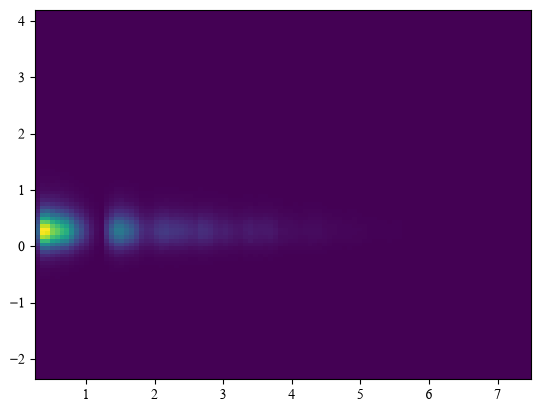

In [48]:
plt.hist2d(gb_distance/grid.spacing[0], dislo_triax_flat, bins = 100)

In [49]:
gb_voxel_distance_bins = np.linspace(min(gb_distance/grid.spacing[0]), max(gb_distance/grid.spacing[0]), 50)
gb_voxel_distance_bin_indices = np.digitize(gb_distance/grid.spacing[0], bins = gb_voxel_distance_bins)

In [50]:
median_pheno_triax_voxels = []
median_dislo_triax_voxels = []
mean_pheno_triax_voxels = []
mean_dislo_triax_voxels = []
pheno_q5_voxels = []
dislo_q5_voxels = []
pheno_q95_voxels = []
dislo_q95_voxels = []
bin_centres_voxels = []

for i in range(1, len(gb_voxel_distance_bins)):
    mask_voxels = gb_voxel_distance_bin_indices == i

    if np.any(mask_voxels) and (np.sum(gb_voxel_distance_bin_indices == i) > 50):
        pheno_voxels_vals = pheno_triax_flat[mask_voxels]
        dislo_voxels_vals = dislo_triax_flat[mask_voxels]
        median_pheno_triax_voxels.append(np.median(pheno_voxels_vals))
        mean_pheno_triax_voxels.append(np.mean(pheno_voxels_vals))
        median_dislo_triax_voxels.append(np.median(dislo_voxels_vals))
        mean_dislo_triax_voxels.append(np.mean(dislo_voxels_vals))

        pheno_q5_voxels.append(np.percentile(pheno_voxels_vals, 5))
        dislo_q5_voxels.append(np.percentile(dislo_voxels_vals, 5))
        pheno_q95_voxels.append(np.percentile(pheno_voxels_vals, 95))
        dislo_q95_voxels.append(np.percentile(dislo_voxels_vals, 95))

        bin_centres_voxels.append(0.5 * (gb_voxel_distance_bins[i-1] + gb_voxel_distance_bins[i]))

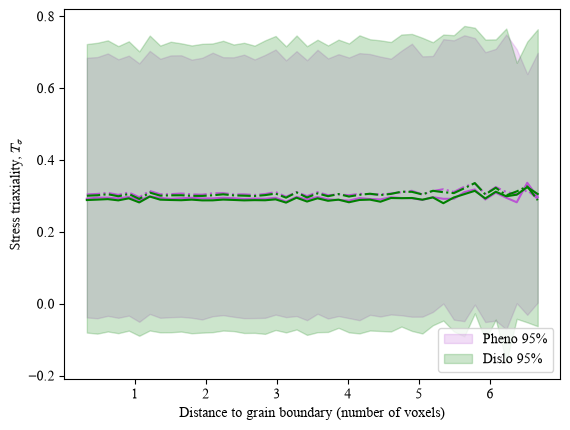

In [51]:
plt.plot(bin_centres_voxels, median_pheno_triax_voxels, color = 'mediumorchid')
plt.plot(bin_centres_voxels, mean_pheno_triax_voxels, color = 'mediumorchid', ls = '-.')
plt.fill_between(bin_centres_voxels, pheno_q5_voxels, pheno_q95_voxels, color = 'mediumorchid', alpha=0.2, label='Pheno 95%')
plt.plot(bin_centres_voxels, median_dislo_triax_voxels, color = 'green')
plt.plot(bin_centres_voxels, mean_dislo_triax_voxels, color = 'green', ls = '-.')
plt.fill_between(bin_centres_voxels, dislo_q5_voxels, dislo_q95_voxels, color = 'green', alpha=0.2, label='Dislo 95%')
plt.xlabel('Distance to grain boundary (number of voxels)')
plt.ylabel(r'Stress triaxiality, $T_\sigma$', math_fontfamily = 'cm')
plt.legend()

Text(0, 0.5, 'Stress triaxiality, $T_\\sigma$')

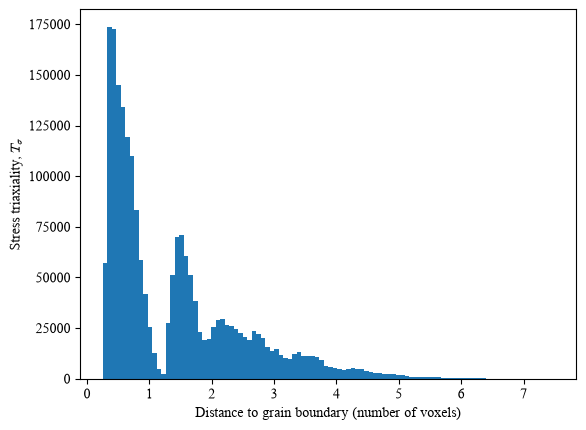

In [ ]:
plt.hist(gb_distance/grid.spacing[0], bins = 100)
plt.xlabel('Distance to grain boundary (number of voxels)')
plt.ylabel(r'Stress triaxiality, $T_\sigma$', math_fontfamily = 'cm')

In [53]:
counts_per_bin_voxels = [np.sum(gb_voxel_distance_bin_indices == i) for i in range(len(gb_voxel_distance_bins))]

In [54]:
np.array(counts_per_bin_voxels), gb_voxel_distance_bins

(array([     0, 238603, 322150, 254449, 191571,  95474,  32948,   9228,
         95548, 143300, 105283,  52783,  42168,  58854,  55168,  49416,
         40727,  45535,  38455,  29311,  23661,  21724,  25000,  23104,
         20786,  12687,  10515,   9646,  10489,   8845,   6284,   4972,
          4558,   3497,   2382,   1902,   1861,   1370,    989,    619,
           388,    298,    266,    166,     87,     40,     23,     13,
             6,      2]),
 array([0.25295638, 0.40053439, 0.54811241, 0.69569043, 0.84326845,
        0.99084647, 1.13842449, 1.28600251, 1.43358053, 1.58115855,
        1.72873657, 1.87631459, 2.0238926 , 2.17147062, 2.31904864,
        2.46662666, 2.61420468, 2.7617827 , 2.90936072, 3.05693874,
        3.20451676, 3.35209478, 3.49967279, 3.64725081, 3.79482883,
        3.94240685, 4.08998487, 4.23756289, 4.38514091, 4.53271893,
        4.68029695, 4.82787497, 4.97545298, 5.123031  , 5.27060902,
        5.41818704, 5.56576506, 5.71334308, 5.8609211 , 6.00849912

In [55]:
mask_triax_close_to_gb = gb_voxel_distance_bin_indices == 1

In [56]:
pheno_triax_close_to_gb = pheno_triax_flat[mask_triax_close_to_gb]
dislo_triax_close_to_gb = dislo_triax_flat[mask_triax_close_to_gb]
gb_voxel_distance_close_to_gb = gb_distance[mask_triax_close_to_gb]

Text(0, 0.5, 'Stress triaxiality, $T_\\sigma$')

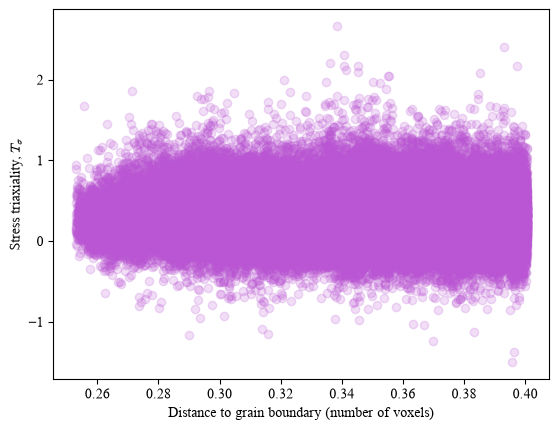

In [57]:
plt.scatter(gb_voxel_distance_close_to_gb/grid.spacing[0], pheno_triax_close_to_gb, color = 'mediumorchid', alpha = 0.2)
#plt.scatter(gb_voxel_distance_close_to_gb/grid.spacing[0], dislo_triax_close_to_gb, color = 'g', alpha = 0.2)
plt.xlabel('Distance to grain boundary (number of voxels)')
plt.ylabel(r'Stress triaxiality, $T_\sigma$', math_fontfamily = 'cm')

# 1. Distribution of voxels where $T_{\sigma,dislo}$ > $T_{\sigma,pheno}$, and both > 0

In [58]:
pheno_triax_flat, dislo_triax_flat

(array([0.31364742, 0.47357737, 0.29512095, ..., 0.26727335, 0.38927275,
        0.26083154], shape=(2097152,)),
 array([0.40417468, 0.41834272, 0.05064398, ..., 0.18500388, 0.36028864,
        0.39336371], shape=(2097152,)))

In [59]:
# First find all values where both DD and phenopowerlaw CP predict stress triaxiality > 0
pheno_roi_1 = pheno_triax_flat
dislo_roi_1 = dislo_triax_flat
gb_distances_roi_1 = gb_distance
for i in range(len(pheno_roi_1)):
    if not (dislo_roi_1[i] > 0 and pheno_roi_1[i] > 0 and dislo_roi_1[i] > pheno_roi_1[i]):
        pheno_roi_1[i] = np.nan
        dislo_roi_1[i] = np.nan
        gb_distances_roi_1[i] = np.nan

In [60]:
pheno_masked_vals_1 = np.array([val for val in pheno_roi_1 if not np.isnan(val)])
dislo_masked_vals_1 = np.array([val for val in dislo_roi_1 if not np.isnan(val)])
gb_distances_masked_vals_1 = np.array([val for val in gb_distances_roi_1 if not np.isnan(val)])

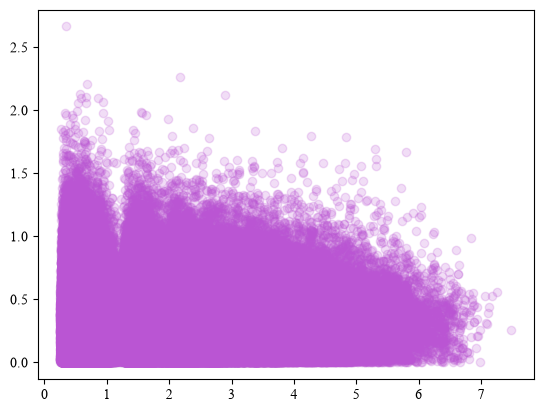

In [61]:
plt.scatter(gb_distances_masked_vals_1/grid.spacing[0], pheno_masked_vals_1, color = 'mediumorchid', alpha = 0.2)

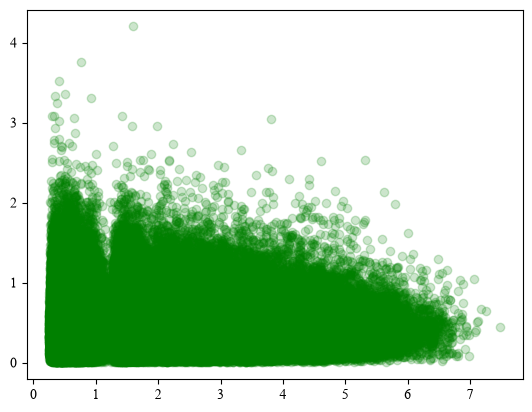

In [62]:
plt.scatter(gb_distances_masked_vals_1/grid.spacing[0], dislo_masked_vals_1, color = 'g', alpha = 0.2)

# 2. Distribution of voxels where $T_{\sigma,pheno}$ > $T_{\sigma,dislo}$, and both > 0

In [66]:
gb_distance

array([3.42271070e-06, 3.38770329e-06, 3.35261032e-06, ...,
       1.02153425e-05, 1.39878698e-05, 1.69543576e-05], shape=(2097152,))

In [67]:
pheno_roi_2 = pheno_triax.flatten(order = 'F')
dislo_roi_2 = dislo_triax.flatten(order = 'F')
gb_distances_roi_2 = tree.query(voxel_coords.reshape(-1,voxel_coords.shape[-1]), workers=8,p=2)[0]
for i in range(len(pheno_roi_2)):
    if not (dislo_roi_2[i] > 0 and pheno_roi_2[i] > 0 and pheno_roi_2[i] > dislo_roi_2[i]):
        pheno_roi_2[i] = np.nan
        dislo_roi_2[i] = np.nan
        gb_distances_roi_2[i] = np.nan

In [68]:
pheno_masked_vals_2 = np.array([val for val in pheno_roi_2 if not np.isnan(val)])
dislo_masked_vals_2 = np.array([val for val in dislo_roi_2 if not np.isnan(val)])
gb_distances_masked_vals_2 = np.array([val for val in gb_distances_roi_2 if not np.isnan(val)])

In [69]:
len(pheno_masked_vals_2), len(dislo_masked_vals_2), len(gb_distances_masked_vals_2)

(934828, 934828, 934828)

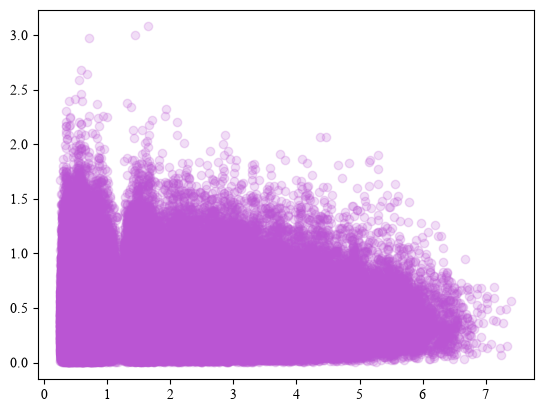

In [70]:
plt.scatter(gb_distances_masked_vals_2/grid.spacing[0], pheno_masked_vals_2, color = 'mediumorchid', alpha = 0.2)

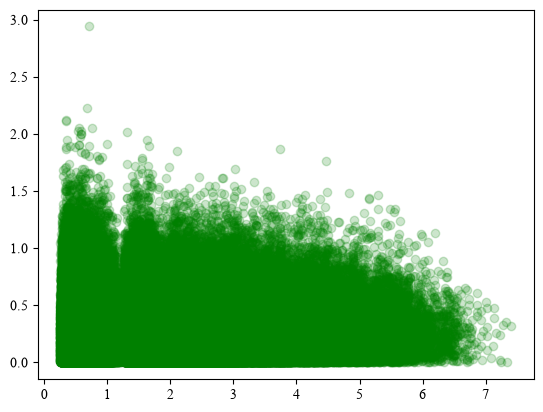

In [71]:
plt.scatter(gb_distances_masked_vals_2/grid.spacing[0], dislo_masked_vals_2, color = 'g', alpha = 0.2)

# 3. Identifying differences between regions of high (> 1) stress triaxiality for each CP model

In [89]:
pheno_high_triax = pheno_triax.flatten(order = 'F')
dislo_high_triax = dislo_triax.flatten(order = 'F')
gb_distances_pheno_high_triax = tree.query(voxel_coords.reshape(-1,voxel_coords.shape[-1]), workers=8,p=2)[0]
gb_distances_dislo_high_triax = tree.query(voxel_coords.reshape(-1,voxel_coords.shape[-1]), workers=8,p=2)[0]

In [96]:
sorted_pheno_high_triax = sorted(pheno_high_triax)
sorted_dislo_high_triax = sorted(dislo_high_triax)

In [97]:
sorted_pheno_high_triax[-99:], sorted_dislo_high_triax[-99:]

([np.float64(1.940773774012525),
  np.float64(1.9415446455939378),
  np.float64(1.9459807856571136),
  np.float64(1.9466936591952688),
  np.float64(1.9477171229901078),
  np.float64(1.9498547644100748),
  np.float64(1.9582188385969412),
  np.float64(1.959383496991698),
  np.float64(1.9595261925630905),
  np.float64(1.9608092607489693),
  np.float64(1.9617077769732416),
  np.float64(1.9630173716042225),
  np.float64(1.9647867293924792),
  np.float64(1.9677556838016976),
  np.float64(1.9683780749787436),
  np.float64(1.96962916425257),
  np.float64(1.9767941854341358),
  np.float64(1.9794588700258582),
  np.float64(1.980900214615595),
  np.float64(1.9817656077981234),
  np.float64(1.982423711160056),
  np.float64(1.9848001933070485),
  np.float64(1.9862641359106032),
  np.float64(1.988639564823016),
  np.float64(1.9913986405869668),
  np.float64(1.9927557591436862),
  np.float64(1.9966852187879751),
  np.float64(1.9997202277193833),
  np.float64(2.003465671852276),
  np.float64(2.0157219

In [ ]:
pheno_high_triax = np.array([val for val in pheno_high_triax if val > 1])
gb_distances_pheno_high_triax = np.array([val for val in gb_distances_high_triax if val > 2])
dislo_high_triax = dislo_high_triax[dislo_high_triax > 2]
gb_distances_dislo_high_triax = gb_distances_dislo_high_triax[np.where(dislo_high_triax > 2)]

In [83]:
len(pheno_high_triax), len(dislo_high_triax)

(71, 268)

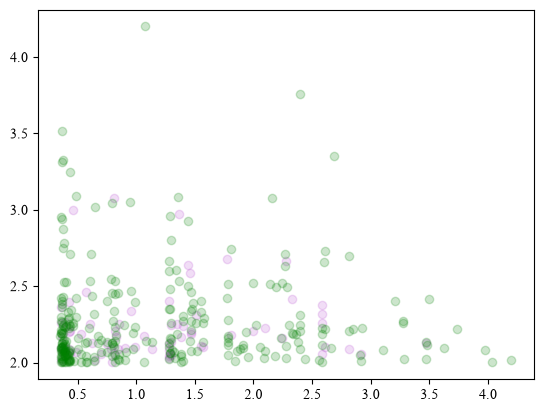

In [82]:
plt.scatter(gb_distances_pheno_high_triax/grid.spacing[0], pheno_high_triax, color = 'mediumorchid', alpha = 0.2)
plt.scatter(gb_distances_dislo_high_triax/grid.spacing[0], dislo_high_triax, color = 'g', alpha = 0.2)

Conclusions: Distributions of 